# The Great Moderation: dating a fall in US growth volatility

One of the most studied facts in modern macroeconomics is the *Great Moderation*: starting in the mid-1980s, the volatility of US real-GDP growth fell sharply and stayed low for two decades. Kim & Nelson (1999) and McConnell & Perez-Quiros (2000) dated the variance break to 1984:Q1, and Stock & Watson (2002) catalogued the breadth of the decline. Here we recover this pattern from the growth series alone, dating the break, quantifying the drop, and tracking the renewed rise in volatility in 2008, without telling the model in advance when anything happened.

This is a natural application for *bayesloop*, and it makes use of a feature not exercised by the other examples: two parameters that vary in time simultaneously. We model quarterly growth as Gaussian and let both its mean (trend growth) and its standard deviation (volatility) drift in time, driven by two independent random walks that are combined with a `CombinedTransitionModel`. A `HyperStudy` then marginalises over both random-walk step sizes at once, a two-dimensional hyper-parameter inference that is visualised below as a joint posterior, while a `ChangepointStudy` scans every quarter to date the variance break and attach a credible interval to it.

<div style="background-color: #ffedcc; border-left: 5px solid #f0b37e; padding: 0.5em; margin-top: 1em; margin-bottom: 1.0em">
**DISCLAIMER:** This website does not provide tax, legal or accounting advice. This material has been prepared for informational purposes only, and is not intended to provide, and should not be relied on for, tax, legal or accounting advice. You should consult your own tax, legal and accounting advisors before engaging in any transaction.
</div>

In [1]:
%matplotlib inline
import io
import urllib.request

import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt

import bayesloop as bl

try:
    import seaborn as sns
    sns.set_style("whitegrid")
except ImportError:
    plt.style.use("default")
mpl.rcParams.update({
    "figure.dpi": 110, "font.size": 10.5, "axes.titlesize": 12,
    "axes.titleweight": "bold", "axes.edgecolor": "#444444", "grid.color": "#d9d9d9",
})
C = {"data": "#8a8a8a", "accent": "#c1272d", "accent2": "#0b6e99",
     "green": "#2e7d32", "amber": "#e8a33d", "muted": "#8a8a8a",
     "band": "#c1272d", "band2": "#0b6e99"}


def posterior_band(S, name, lo=0.05, hi=0.95):
    """Posterior mean and an equal-tailed credible band for a time-varying parameter."""
    x, p = S.get_parameter_distributions(name, density=False)
    p = np.asarray(p, dtype=float)
    p /= p.sum(axis=1, keepdims=True)
    mean = (p * x[None, :]).sum(axis=1)
    cdf = np.cumsum(p, axis=1)
    low = np.array([np.interp(lo, cdf[t], x) for t in range(p.shape[0])])
    high = np.array([np.interp(hi, cdf[t], x) for t in range(p.shape[0])])
    return mean, low, high


def prob_in(S, name, lo=None, hi=None):
    """Posterior probability the parameter lies in (lo, hi] at each time step."""
    x, p = S.get_parameter_distributions(name, density=False)
    p = np.asarray(p, dtype=float)
    p /= p.sum(axis=1, keepdims=True)
    mask = np.ones_like(x, dtype=bool)
    if lo is not None:
        mask &= x > lo
    if hi is not None:
        mask &= x <= hi
    return p[:, mask].sum(axis=1)

## The data

We use quarterly US real GDP (chained dollars), the canonical [FRED series GDPC1](https://fred.stlouisfed.org/series/GDPC1). FRED serves the series as a plain CSV, so the cell below fetches it live (with a `User-Agent` header). From the level we compute annualised quarterly log-growth, gₜ = 400·Δlog(GDPₜ).

The 2020 COVID quarters lie far off the chart, at roughly −33% then +30% annualised, and would dominate any Gaussian volatility scale, so the main analysis runs 1947:Q2–2019:Q4 and we discuss COVID separately. For portability the cell falls back to a public GitHub mirror of the identical GDPC1 series if FRED is unreachable; the two agree to rounding on this window.

In [2]:
def _read_gdpc1():
    """Quarterly real GDP (GDPC1) as a (date, gdp) frame — live from FRED, mirror as fallback."""
    ua = {"User-Agent": "Mozilla/5.0 (bayesloop docs; research)"}
    # Primary: FRED's CSV export. Columns are [observation_date, GDPC1].
    try:
        url = "https://fred.stlouisfed.org/graph/fredgraph.csv?id=GDPC1"
        raw = urllib.request.urlopen(
            urllib.request.Request(url, headers=ua), timeout=60).read()
        d = pd.read_csv(io.BytesIO(raw))
        d.columns = ["date", "gdp"]
        return d
    except Exception:  # noqa: BLE001
        pass  # network-restricted environments fall back to the identical series mirrored below
    # Fallback: datahub 'gdp-us' package; 'level-chained' is exactly GDPC1.
    url = "https://raw.githubusercontent.com/datasets/gdp-us/main/data/quarter.csv"
    raw = urllib.request.urlopen(
        urllib.request.Request(url, headers=ua), timeout=60).read()
    d = pd.read_csv(io.BytesIO(raw))[["date", "level-chained"]]
    d.columns = ["date", "gdp"]
    return d


df = _read_gdpc1()
df["date"] = pd.to_datetime(df["date"])
df["g"] = 400 * np.log(df["gdp"]).diff()     # annualised % quarterly log-growth
df = df.dropna()
main = df[(df["date"] >= "1947-04-01") & (df["date"] <= "2019-12-31")].reset_index(drop=True)
t = main["date"].dt.year + (main["date"].dt.month - 1) / 12.0
g = main["g"].values
tt = t.values
print(f"Quarters: {len(g)}  {main.date.min().date()}..{main.date.max().date()}")

Quarters: 291  1947-04-01..2019-10-01


## A Gaussian model with a time-varying mean and volatility

The observation model treats each quarter's growth as Gaussian, but now both parameters are free to move in time: the `mean` is trend growth, and `vol` is the standard deviation we are really after.

```python
bl.om.Gaussian("mean", ..., "vol", ...)
```

For their dynamics we give each parameter its own `GaussianRandomWalk` and combine them with a `CombinedTransitionModel`. Wrapped in a `HyperStudy`, the two random-walk step sizes, `s_mean` (how fast trend growth may drift) and `s_vol` (how fast volatility may drift), are inferred jointly by marginalising over both grids at once.

In [3]:
def gauss():
    return bl.om.Gaussian("mean", bl.cint(-2, 7, 90), "vol", bl.oint(0.3, 8, 80))

Sv = bl.HyperStudy()
Sv.load_data(g, timestamps=tt)
Sv.set(gauss(),
       bl.tm.CombinedTransitionModel(
           bl.tm.GaussianRandomWalk("s_mean", bl.cint(0, 0.6, 16), target="mean"),
           bl.tm.GaussianRandomWalk("s_vol", bl.cint(0, 1.2, 18), target="vol")))
Sv.fit(n_jobs=4, silent=True)
mean_m, mean_lo, mean_hi = posterior_band(Sv, "mean")
vol_m, vol_lo, vol_hi = posterior_band(Sv, "vol")

+ Created new study.
  --> Hyper-study
+ Successfully imported array.
+ Observation model: Gaussian observations. Parameter(s): ['mean', 'vol']
+ Transition model: Combined transition model. Hyper-Parameter(s): ['s_mean', 's_vol']


## Comparing static, drifting and single-break models

Because every model below shares the identical observation model and data, their log₁₀ marginal likelihoods (`S.log10_evidence`) are directly comparable. We compare three hypotheses:

| Hypothesis | Transition model |
|---|---|
| Static (constant) | `tm.Static()` |
| Time-varying (drift) | the `CombinedTransitionModel` above |
| Single change-point | `tm.ChangePoint("t_change", "all")` |

The `ChangepointStudy` scans every quarter for the single dominant structural break in the parameters, which is how we date the variance break and put a credible interval on it.

In [4]:
S0 = bl.Study(); S0.load_data(g, timestamps=tt); S0.set(gauss(), bl.tm.Static()); S0.fit(silent=True)
Scp = bl.ChangepointStudy(); Scp.load_data(g, timestamps=tt)
Scp.set(gauss(), bl.tm.ChangePoint("t_change", "all")); Scp.fit(n_jobs=4, silent=True)
cp_x, cp_p = Scp.get_hyper_parameter_distribution("t_change")
cp_mode = float(cp_x[np.argmax(cp_p)])
order = np.argsort(cp_p)[::-1]; cum = np.cumsum(cp_p[order])
cred = np.sort(cp_x[order[:np.searchsorted(cum, 0.90) + 1]])

evid = {
    "Static (constant)": float(S0.log10_evidence),
    "Time-varying (drift)": float(Sv.log10_evidence),
    "Single change-point": float(Scp.log10_evidence),
}

# Joint posterior over the two random-walk step sizes — a genuine 2-D HyperStudy:
# the trend-growth smoothness (s_mean) and the volatility smoothness (s_vol) are inferred
# jointly, and the joint distribution shows they are well-identified and near-independent.
jx, jy, jp = Sv.get_joint_hyper_parameter_distribution(["s_mean", "s_vol"])
hyper_s_mean_mode = float(jx[np.argmax(jp.sum(axis=1))])
hyper_s_vol_mode = float(jy[np.argmax(jp.sum(axis=0))])

# Empirical volatility before/after 1984; inferred volatility drop.
pre = main[(main.date.dt.year >= 1947) & (main.date.dt.year <= 1983)]["g"].std()
post = main[(main.date.dt.year >= 1984) & (main.date.dt.year <= 2007)]["g"].std()
emp_vol_ratio = float(pre / post)
vol_1980 = vol_m[np.argmin(np.abs(tt - 1980))]
vol_1995 = vol_m[np.argmin(np.abs(tt - 1995))]

print("\nMODEL EVIDENCE (log10):")
for k, v in evid.items():
    print(f"  {k:22s} {v:9.2f}")
print(f"Change-point dated to {cp_mode:.1f} (90% credible {cred.min():.1f}-{cred.max():.1f})")
print(f"Empirical growth volatility: 1947-83 = {pre:.2f}%, 1984-2007 = {post:.2f}%  ({pre/post:.2f}x)")
print(f"Inferred volatility: 1980 ~ {vol_1980:.2f}%  ->  1995 ~ {vol_1995:.2f}%")

+ Created new study.
+ Successfully imported array.
+ Observation model: Gaussian observations. Parameter(s): ['mean', 'vol']
+ Transition model: Static/constant parameter values. Hyper-Parameter(s): []
+ Created new study.
  --> Hyper-study
  --> Change-point analysis
+ Successfully imported array.
+ Observation model: Gaussian observations. Parameter(s): ['mean', 'vol']
+ Transition model: Change-point. Hyper-Parameter(s): ['t_change']
+ Detected 1 change-point(s) in transition model: ['t_change']
+ Set hyper-prior(s): ['uniform']



MODEL EVIDENCE (log10):
  Static (constant)        -348.11
  Time-varying (drift)     -330.40
  Single change-point      -338.20
Change-point dated to 1984.2 (90% credible 1983.8-1985.5)
Empirical growth volatility: 1947-83 = 4.69%, 1984-2007 = 2.03%  (2.31x)
Inferred volatility: 1980 ~ 5.22%  ->  1995 ~ 1.92%


The bottom panel below shows the Great Moderation directly. The inferred volatility sits at around 5–6% from 1947 to 1983, drops to about 2% around 1984, rises during the 2008 financial crisis (amber), and returns to a low level afterward. The top panel shows trend growth drifting gently down from around 4% to 2½% over the same period, the slower "secular" story, cleanly separated from the volatility story by the two independent random walks.

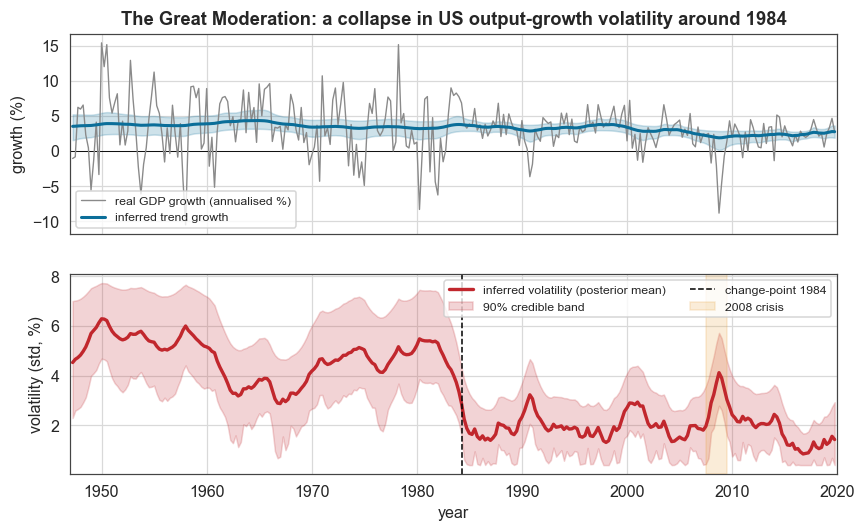

In [5]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(9, 5.2), sharex=True)
ax1.axhline(0, color="k", lw=0.6)
ax1.plot(tt, g, color=C["muted"], lw=0.9, label="real GDP growth (annualised %)")
ax1.plot(tt, mean_m, color=C["accent2"], lw=2, label="inferred trend growth")
ax1.fill_between(tt, mean_lo, mean_hi, color=C["band2"], alpha=0.2)
ax1.set_ylabel("growth (%)")
ax1.set_title("The Great Moderation: a collapse in US output-growth volatility around 1984")
ax1.legend(loc="lower left", fontsize=8)

ax2.plot(tt, vol_m, color=C["accent"], lw=2.2, label="inferred volatility (posterior mean)")
ax2.fill_between(tt, vol_lo, vol_hi, color=C["band"], alpha=0.2, label="90% credible band")
ax2.axvline(cp_mode, color="k", ls="--", lw=1, label=f"change-point {cp_mode:.0f}")
ax2.axvspan(2007.5, 2009.5, color=C["amber"], alpha=0.2, label="2008 crisis")
ax2.set_ylabel("volatility (std, %)")
ax2.set_xlabel("year")
ax2.legend(loc="upper right", ncol=2, fontsize=8)
ax2.set_xlim(1947, 2020)
plt.show()

## Dating the break and scoring the models

Forced to place a single break, the `ChangepointStudy` posterior concentrates almost exactly where the classical literature placed it. The change-point is dated to around 1984:Q1, with a tight 90% credible interval around 1984, essentially the break McConnell & Perez-Quiros (2000) identified with classical methods, but now with an uncertainty attached that a fixed before/after split could never give.

On the right, the time-varying model clearly outperforms the static model, by roughly 18 log₁₀ units (a factor of around 10¹⁸). The gradual-drift model also outperforms the single change-point: the data are best described as a low-volatility regime established in 1984 but with further evolution (the 2008 spike, the even quieter 2010s) that one clean break cannot capture.

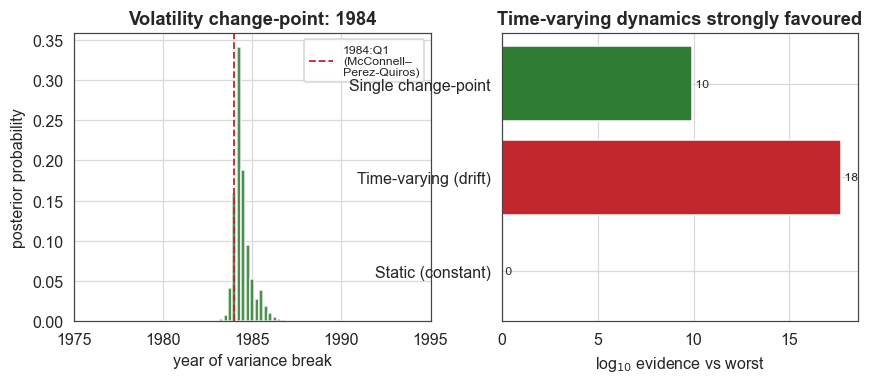

In [6]:
fig, (axa, axb) = plt.subplots(1, 2, figsize=(9.2, 3.4))
axa.bar(cp_x, cp_p, width=(cp_x[1] - cp_x[0]) * 0.9, color=C["green"], alpha=0.85)
axa.axvline(1984, color=C["accent"], ls="--", lw=1.2, label="1984:Q1\n(McConnell–\nPerez-Quiros)")
axa.set_xlim(1975, 1995)
axa.set_xlabel("year of variance break")
axa.set_ylabel("posterior probability")
axa.set_title(f"Volatility change-point: {cp_mode:.0f}")
axa.legend(fontsize=8)
labels = list(evid.keys())
vals = np.array([evid[k] for k in labels]) - min(evid.values())
axb.barh(labels, vals, color=[C["muted"], C["accent"], C["green"]])
axb.set_xlabel(r"log$_{10}$ evidence vs worst")
axb.set_title("Time-varying dynamics strongly favoured")
for i, v in enumerate(vals):
    axb.text(v, i, f" {v:.0f}", va="center", fontsize=8)
plt.show()

Empirically, growth volatility fell from 4.69% (1947–1983) to 2.03% (1984–2007), a 2.3-fold reduction. The smooth bayesloop estimate is even sharper across the break, from around 5.2% (1980) to around 1.9% (1995).

## The joint posterior of the two smoothness hyper-parameters

Because both step sizes were marginalised inside one `HyperStudy`, we can read off their joint posterior with `get_joint_hyper_parameter_distribution`. It shows that trend smoothness (`s_mean`) and volatility smoothness (`s_vol`) are each well-identified with interior modes (s_mean ≈ 0.12, s_vol ≈ 0.42) and essentially independent: the two kinds of dynamics are separately learned from the data, not assumed. This is the part of the toolbox built for models whose parameters have dynamics of their own.

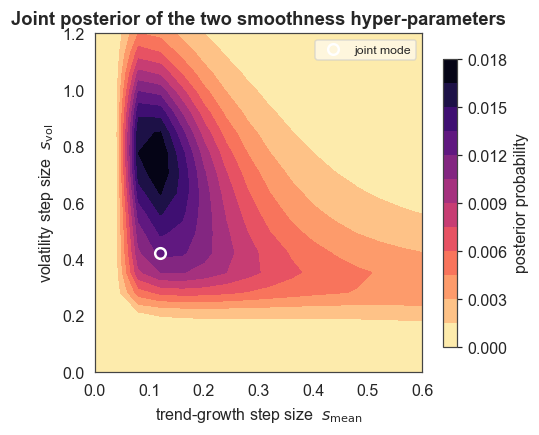

In [7]:
fig, ax = plt.subplots(figsize=(4.8, 4.0))
cf = ax.contourf(jx, jy, jp.T, levels=14, cmap="magma_r")
ax.plot(hyper_s_mean_mode, hyper_s_vol_mode, "o", ms=7,
        mfc="none", mec="white", mew=1.6, label="joint mode")
ax.set_xlabel(r"trend-growth step size  $s_{\mathrm{mean}}$")
ax.set_ylabel(r"volatility step size  $s_{\mathrm{vol}}$")
ax.set_title("Joint posterior of the two smoothness hyper-parameters")
ax.legend(loc="upper right", fontsize=8, framealpha=0.6)
plt.colorbar(cf, ax=ax, shrink=0.85, label="posterior probability")
plt.show()

## What this example showed

On a single, much-studied macro series we used *bayesloop* to:

- track two time-varying parameters at once, trend growth and volatility, disentangled
  by a `CombinedTransitionModel` and a two-dimensional `HyperStudy` whose joint posterior over the
  two random-walk step sizes shows both are well-identified and near-independent;
- re-derive a textbook econometric result with a credible interval, with the variance break
  landing at around 1984:Q1, matching McConnell & Perez-Quiros (2000), but now with uncertainty
  on the date instead of a hand-picked split;
- quantify the moderation, a roughly 2.3× drop in growth volatility (4.69% → 2.03%
  empirically; around 5.2% → around 1.9% in the smooth estimate), with the 2008 spike and the
  post-crisis return to calm visible in the continuous trajectory;
- let the evidence settle the story, with the time-varying model outperforming the static model by around 18 log₁₀
  units, and also outperforming a single change-point, indicating that the moderation is a regime together with
  ongoing evolution, not one clean step.

The 2020 COVID quarters are excluded because their extreme values would dominate the Gaussian volatility scale.